In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.globals as gl

In [4]:
def heatmap_annotate(df_to_plot, ds_order, ax, ds_order_y=None, column=['train_dataset'], row=['eval_dataset'], value=['R_eval'], cmap='inferno', vmin=0, vmax=0.5, cbar=True):
    if ds_order_y is None:
        if 'Fusion' in ds_order:
            ds_order_y = [ds for ds in ds_order if ds!='Fusion']
        else:
            ds_order_y = ds_order
    V = pd.pivot_table(df_to_plot, columns=column, index=row, values=value)
    V = V.reindex(ds_order_y, axis=0)
    V = V.reindex(ds_order, level=1, axis=1)

    sns.heatmap(V.values, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax, 
                xticklabels=V.columns.get_level_values(1).values, 
                yticklabels=V.index.values, square=True, ax=ax, cbar=cbar)
    if 'Fusion' in ds_order or 'Global' in ds_order:
        ax.axvline(len(ds_order_y), color='k', linewidth=1.5)

    return ax

In [5]:
train_ds_list = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]
eval_names = ["MDTB", "Languagelocalizer", "Socialsocial", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]

df_L2reg = pd.DataFrame()
df_NNLS = pd.DataFrame()
for i, ds in enumerate(train_ds_list):
    eval_data = [ev_ds for ev_ds in eval_names if ev_ds != ds]

    # load group
    df_1 = rm.comb_eval(models=[f'{ds}-group-Cavg'], eval_data=eval_data, methods=["L2reg", "NNLS"], cerebellum="MNISymC3")

    # load loo
    df_2 = rm.comb_eval(models=[f'{ds}-group_loo-Cavg'], eval_data=[eval_names[i]], methods=["L2reg", "NNLS"], cerebellum="MNISymC3")

    df_L2reg = pd.concat([df_L2reg, df_1[df_1['method'] == 'L2reg'], df_2[df_2['method'] == 'L2reg']])
    df_NNLS = pd.concat([df_NNLS, df_1[df_1['method'] == 'NNLS'], df_2[df_2['method'] == 'NNLS']])
df_NNLS.logalpha.fillna(-np.inf, inplace=True)

In [6]:
# group L2reg
A = pd.pivot_table(df_L2reg[df_L2reg.model=='group'], index=['train_dataset'],
                   columns=['logalpha'],values=['R_eval'],aggfunc='mean').reindex(train_ds_list)
display(A)
B = np.nan_to_num(A.values)
ind = B.argmax(axis=1)
log_a = np.array(A.columns.get_level_values(1)[ind])
bestla = pd.DataFrame(log_a,index=A.index,columns=['best_logalpha'])
display(bestla)
df_L2reg['isbest'] = df_L2reg.logalpha.values == bestla.loc[df_L2reg.train_dataset].values.flatten()

R_eval                                                    \
logalpha           0.0       2.0       4.0       6.0       8.0       10.0   
train_dataset                                                               
MDTB           0.187755  0.206722  0.244275  0.264902  0.258568  0.240413   
Language       0.204224  0.209875  0.228611  0.244915  0.239533  0.227668   
Social         0.145358  0.151137  0.171857  0.195664  0.200175  0.196911   
WMFS           0.083141  0.097642  0.149962  0.193786  0.183051  0.165538   
Demand         0.116298  0.130655  0.160821  0.169699  0.163132  0.155990   
Somatotopic   -0.064325 -0.060734 -0.022593  0.045958  0.062468  0.060679   
Nishimoto      0.070352  0.091760  0.158556  0.223638  0.239896  0.231746   
IBC            0.222536  0.239466  0.248270  0.248911  0.248191  0.224020   
HCPur100       0.270963  0.277102  0.247450  0.218111  0.210237  0.209006   

                         
logalpha           12.0  
train_dataset            
MDTB           0.231287  
Language       0.224001  
Social         0.195518  
WMFS           0.160259  
Demand         0.153885  
Somatotopic    0.059334  
Nishimoto      0.218826  
IBC            0.199778  
HCPur100       0.208835

,best_logalpha
train_dataset,
MDTB,6.0
Language,6.0
Social,8.0
WMFS,6.0
Demand,6.0
Somatotopic,8.0
Nishimoto,8.0
IBC,6.0
HCPur100,2.0


In [7]:
# group NNLS
A = pd.pivot_table(df_NNLS[df_NNLS.model=='group'], index=['train_dataset'],
                   columns=['logalpha'],values=['R_eval'],aggfunc='mean').reindex(train_ds_list)
display(A)
B = np.nan_to_num(A.values)
ind = B.argmax(axis=1)
log_a = np.array(A.columns.get_level_values(1)[ind])
bestla = pd.DataFrame(log_a,index=A.index,columns=['best_logalpha'])
display(bestla)
df_NNLS['isbest'] = df_NNLS.logalpha.values == bestla.loc[df_NNLS.train_dataset].values.flatten()

R_eval                                        
logalpha           -inf       0.0       2.0       4.0       6.0
train_dataset                                                  
MDTB           0.256151  0.264730  0.258491  0.244937  0.233710
Language       0.162270  0.244721  0.245183  0.234715  0.221660
Social         0.112107  0.208649  0.208690  0.199861  0.191330
WMFS           0.106343  0.156481  0.154227  0.153893  0.153847
Demand         0.104244  0.173041  0.174059  0.167073  0.160081
Somatotopic    0.075963  0.089453  0.087200  0.086831  0.086780
Nishimoto      0.225191  0.241046  0.238088  0.223897  0.209830
IBC            0.187168  0.223403  0.220762  0.203210  0.186741
HCPur100       0.199653  0.276349  0.269995  0.235287  0.209582

,best_logalpha
train_dataset,
MDTB,0.0
Language,2.0
Social,2.0
WMFS,0.0
Demand,2.0
Somatotopic,0.0
Nishimoto,0.0
IBC,0.0
HCPur100,0.0


#### load global models

In [8]:
### load global model
df_global_NNLS = pd.DataFrame()
df_global_L2reg = pd.DataFrame()
for i,ds in enumerate(train_ds_list):
    d = gl.datasets.index(ds)
    train_dscode = ''.join(gl.dscode[:d]+gl.dscode[d+1:])
    df = rm.comb_eval(models=[f'{train_dscode}-global-Cavg'], methods=['L2reg'], eval_data=[eval_names[i]], cerebellum='MNISymC3')
    df_global_L2reg = pd.concat([df_global_L2reg, df], ignore_index=True)
    df = rm.comb_eval(models=[f'{train_dscode}-global-Cavg'], methods=['NNLS'], eval_data=[eval_names[i]], cerebellum='MNISymC3')
    df_global_NNLS = pd.concat([df_global_NNLS, df], ignore_index=True)

df_global_NNLS.logalpha.fillna(-np.inf, inplace=True)

In [9]:
A = pd.pivot_table(df_global_L2reg, index=['model'],columns=['logalpha'],values=['R_eval'],aggfunc='mean')
display(A)
B = np.nan_to_num(A.values)
ind = B.argmax(axis=1)
log_a = np.array(A.columns.get_level_values(1)[ind])
bestla = pd.DataFrame(log_a,index=A.index,columns=['best_logalpha'])
display(bestla)
df_global_L2reg['isbest'] = df_global_L2reg.logalpha.values == bestla.loc[df_global_L2reg.model].values.flatten()

R_eval                                                 
logalpha      0.0       2.0      4.0       6.0       8.0       10.0
model                                                              
global    0.290736  0.300752  0.29301  0.265786  0.243763  0.238438

,best_logalpha
model,
global,2.0


In [10]:
A = pd.pivot_table(df_global_NNLS, index=['model'],columns=['logalpha'],values=['R_eval'],aggfunc='mean')
display(A)
B = np.nan_to_num(A.values)
ind = B.argmax(axis=1)
log_a = np.array(A.columns.get_level_values(1)[ind])
bestla = pd.DataFrame(log_a,index=A.index,columns=['best_logalpha'])
display(bestla)
df_global_NNLS['isbest'] = df_global_NNLS.logalpha.values == bestla.loc[df_global_NNLS.model].values.flatten()

R_eval                             
logalpha     -inf      0.0       1.0       2.0
model                                         
global    0.29041  0.29331  0.292853  0.290881

,best_logalpha
model,
global,0.0


In [21]:
df_global_L2reg['train_dataset'] = "Global"
df_global_NNLS['train_dataset'] = "Global"
df_L2reg_best = pd.concat([df_L2reg[df_L2reg['isbest']], df_global_L2reg[df_global_L2reg['isbest']]], ignore_index=True)
df_NNLS_best = pd.concat([df_NNLS[df_NNLS['isbest']], df_global_NNLS[df_global_NNLS['isbest']]], ignore_index=True)

# mean group noise ceiling
df_L2reg_best['group_noiseceil_Y'] = (df_L2reg_best['group_noiseceil_Y_upper'] + df_L2reg_best['group_noiseceil_Y_lower']) / 2
df_NNLS_best['group_noiseceil_Y'] = (df_NNLS_best['group_noiseceil_Y_upper'] + df_NNLS_best['group_noiseceil_Y_lower']) / 2

NC1 = pd.pivot_table(df_L2reg_best, values='group_noiseceil_Y', index='eval_dataset')
NC2 = pd.pivot_table(df_NNLS_best, values='group_noiseceil_Y', index='eval_dataset')

df_L2reg_best['mean_group_noiseceil_Y'] = df_L2reg_best['eval_dataset'].map(NC1['group_noiseceil_Y'])
df_NNLS_best['mean_group_noiseceil_Y'] = df_NNLS_best['eval_dataset'].map(NC2['group_noiseceil_Y'])

df_L2reg_best['R_eval_adj'] = df_L2reg_best['R_eval'] / df_L2reg_best['mean_group_noiseceil_Y']
df_NNLS_best['R_eval_adj'] = df_NNLS_best['R_eval'] / df_NNLS_best['mean_group_noiseceil_Y']

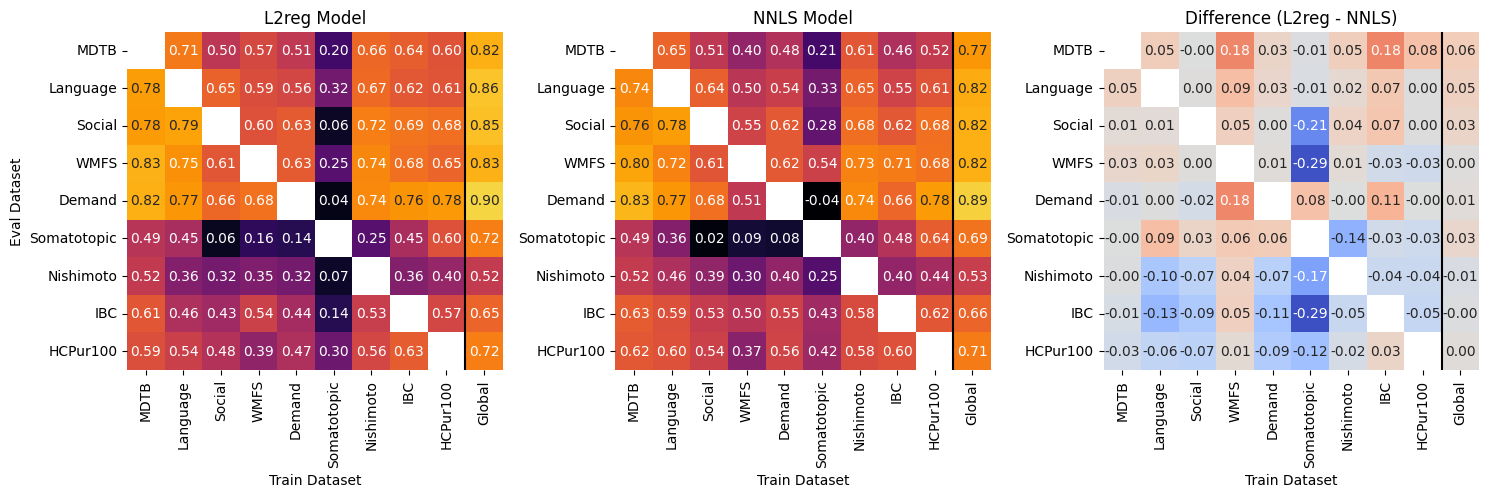

In [22]:
new_order = train_ds_list + ['Global']

fig, axes = plt.subplots(1,3,figsize=(15,5))

ax = heatmap_annotate(df_L2reg_best[df_L2reg_best.model!="group_loo"], ds_order=new_order, ds_order_y=train_ds_list, ax=axes[0], value=['R_eval_adj'],
                      cmap='inferno', vmin=0, vmax=1, cbar=False)
ax.set_title('L2reg Model')
ax.set_xlabel('Train Dataset')
ax.set_ylabel('Eval Dataset')

ax = heatmap_annotate(df_NNLS_best, ds_order=new_order, ds_order_y=train_ds_list, ax=axes[1], value=['R_eval_adj'],
                      cmap='inferno', vmin=0, vmax=1, cbar=False)
ax.set_title('NNLS Model')
ax.set_xlabel('Train Dataset')

# Calculate the difference in 'R_eval_adj' for the same group of (train_dataset, eval_dataset, eval_subj)
df_diff = pd.merge(df_L2reg_best[['train_dataset', 'eval_dataset', 'eval_subj', 'R_eval_adj']],
                   df_NNLS_best[['train_dataset', 'eval_dataset', 'eval_subj', 'R_eval_adj']],
                   on=['train_dataset', 'eval_dataset', 'eval_subj'],
                   suffixes=('_L2reg', '_NNLS'))

df_diff['R_eval_adj_diff'] = df_diff['R_eval_adj_L2reg'] - df_diff['R_eval_adj_NNLS']
ax = heatmap_annotate(df_diff, ds_order=new_order, ds_order_y=train_ds_list, ax=axes[2], value=['R_eval_adj_diff'],
                      cmap='coolwarm', vmin=-0.3, vmax=0.3, cbar=False)
ax.set_title('Difference (L2reg - NNLS)')
ax.set_xlabel('Train Dataset')

plt.tight_layout()

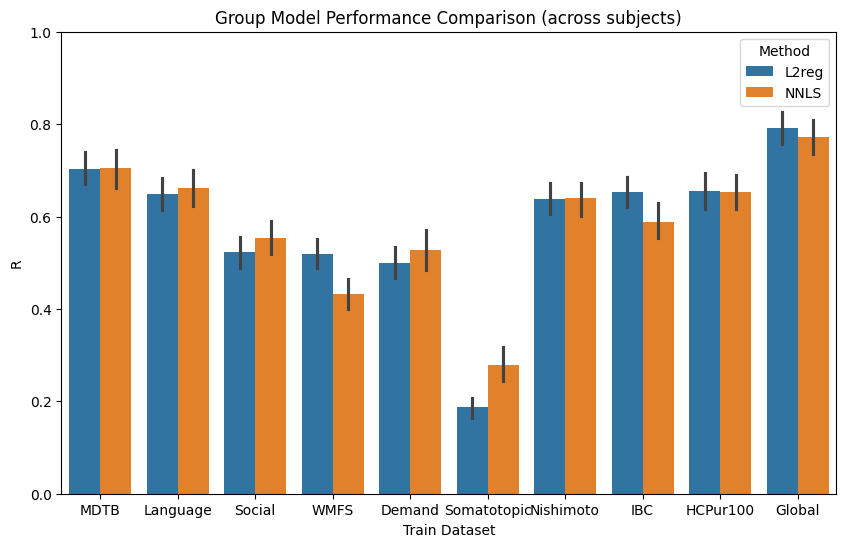

In [27]:
df_all = pd.concat([df_L2reg_best[df_L2reg_best.model!="group_loo"], df_NNLS_best[df_NNLS_best.model!="group_loo"]]).reset_index(drop=True)

plt.figure(figsize=(10,6))
sns.barplot(data=df_all, x='train_dataset', y='R_eval_adj', hue='method', errorbar='ci')
plt.ylim(0,1)
plt.title('Group Model Performance Comparison (across subjects)')
plt.ylabel('R')
plt.xlabel('Train Dataset')
plt.legend(title='Method')
plt.show()

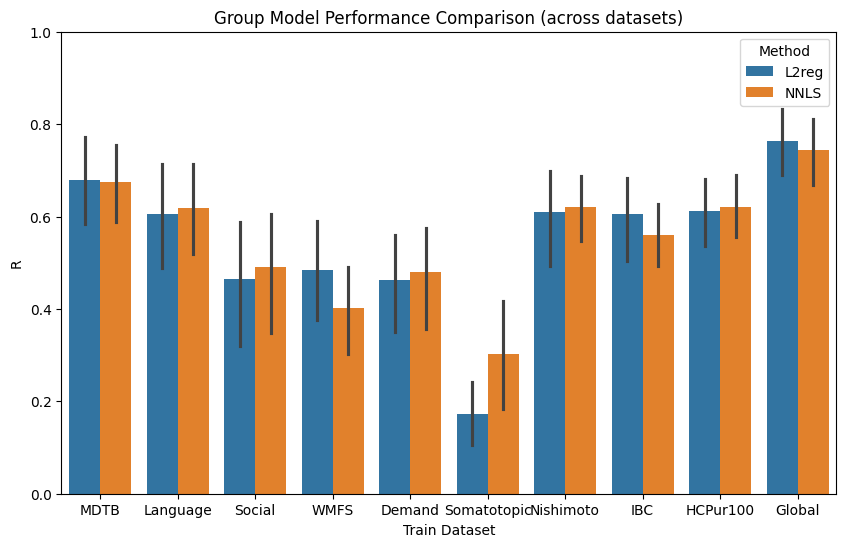

In [28]:
# pivot R_eval_adj by train/eval dataset (mean across subjects), then melt back to long form for plotting
pt_L2 = pd.pivot_table(df_L2reg_best[df_L2reg_best.model!="group_loo"], index='train_dataset', columns='eval_dataset', values='R_eval_adj', aggfunc='mean')
pt_NNLS = pd.pivot_table(df_NNLS_best[df_NNLS_best.model!="group_loo"], index='train_dataset', columns='eval_dataset', values='R_eval_adj', aggfunc='mean')

df_L2_melt = pt_L2.reset_index().melt(id_vars='train_dataset', var_name='eval_dataset', value_name='R_eval_adj')
df_L2_melt['method'] = 'L2reg'

df_NNLS_melt = pt_NNLS.reset_index().melt(id_vars='train_dataset', var_name='eval_dataset', value_name='R_eval_adj')
df_NNLS_melt['method'] = 'NNLS'

df_all = pd.concat([df_L2_melt, df_NNLS_melt], ignore_index=True)

plt.figure(figsize=(10,6))
sns.barplot(data=df_all, x='train_dataset', y='R_eval_adj', hue='method', errorbar='ci', order=new_order)
plt.ylim(0,1)
plt.title('Group Model Performance Comparison (across datasets)')
plt.ylabel('R')
plt.xlabel('Train Dataset')
plt.legend(title='Method')
plt.show()